In [1]:
import importlib
import numpy as np
import pandas as pd
import fitsio as fio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pysr import PySRRegressor
import matplotlib.pyplot as plt

from pathlib import Path

z_bins = np.linspace(0, 7, 100)
bds_tomo = (0.9, 1.2)
lim_tail = bds_tomo[1] + 0.15

ROOT = '/global/cfs/cdirs/desicollab/science/c3/DESI-Lensing/prelim_hscy3/gfarm.ipmu.jp/~surhud/S19ACatalogs/catalog_tracts/'
patches = ['GAMA09H', 'GAMA15H', 'VVDS', 'XMM', 'WIDE12H', 'HECTOMAP']
tracts_dir = {p: ROOT + p + '_tracts/' for p in patches}
files = {p: Path(tracts_dir[p]).glob('pz_pdf_dnnz') for p in patches}

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
tract_id = '9558'
pdffile = ROOT + 'GAMA09H_tracts/' + f'/{tract_id}_pz_pdf_dnnz.fits'
pdf = fio.FITS(pdffile)[1].read()
zfile = ROOT + 'GAMA09H_tracts/' + f'/{tract_id}_pz.fits'
z = fio.FITS(zfile)[1].read()
photfile = ROOT + 'GAMA09H_tracts/' + f'/{tract_id}_no_m.fits'
phot = fio.FITS(photfile)[1].read()

In [3]:
fio.FITS(photfile)[1].get_colnames()

['object_id',
 'parent_id',
 'i_ra',
 'i_dec',
 'i_variance_value',
 'i_kronflux_flux',
 'i_kronflux_fluxerr',
 'i_kronflux_flag',
 'i_kronflux_mag',
 'i_kronflux_magerr',
 'i_cmodel_mag',
 'i_cmodel_magerr',
 'i_cmodel_flag',
 'i_cmodel_flux',
 'i_cmodel_fluxerr',
 'merge_measurement_i',
 'a_g',
 'a_r',
 'a_i',
 'a_z',
 'a_y',
 'forced_g_kronflux_mag',
 'forced_g_kronflux_magerr',
 'forced_g_kronflux_flag',
 'forced_r_kronflux_mag',
 'forced_r_kronflux_magerr',
 'forced_r_kronflux_flag',
 'forced_i_kronflux_mag',
 'forced_i_kronflux_magerr',
 'forced_i_kronflux_flag',
 'forced_z_kronflux_mag',
 'forced_z_kronflux_magerr',
 'forced_z_kronflux_flag',
 'forced_y_kronflux_mag',
 'forced_y_kronflux_magerr',
 'forced_y_kronflux_flag',
 'forced_g_cmodel_mag',
 'forced_g_cmodel_magerr',
 'forced_g_cmodel_flux',
 'forced_g_cmodel_fluxerr',
 'forced_g_cmodel_flag',
 'forced_r_cmodel_mag',
 'forced_r_cmodel_magerr',
 'forced_r_cmodel_flux',
 'forced_r_cmodel_fluxerr',
 'forced_r_cmodel_flag',
 '

(0.0, 2.0)

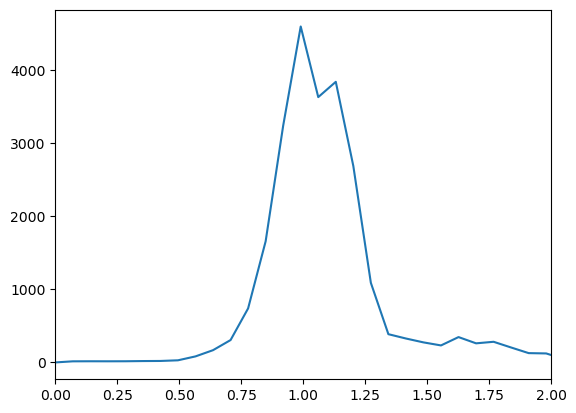

In [4]:
zbin_crit_best = (z['dnnz_photoz_best'] > bds_tomo[0]) & (z['dnnz_photoz_best'] <= bds_tomo[1])
plt.plot(np.linspace(0, 7, 100), np.sum([p[1] for p in pdf[zbin_crit_best]], axis=0), label='PDF')
plt.xlim(0,2)

In [5]:
fio.FITS(zfile)[1].get_colnames()

['object_id',
 'parent_id',
 'i_ra',
 'i_dec',
 'mizuki_photoz_mean',
 'mizuki_photoz_mode',
 'mizuki_photoz_median',
 'mizuki_photoz_best',
 'mizuki_photoz_mc',
 'mizuki_photoz_conf_mean',
 'mizuki_photoz_conf_mode',
 'mizuki_photoz_conf_median',
 'mizuki_photoz_conf_best',
 'mizuki_photoz_risk_mean',
 'mizuki_photoz_risk_mode',
 'mizuki_photoz_risk_median',
 'mizuki_photoz_risk_best',
 'mizuki_photoz_std_mean',
 'mizuki_photoz_std_mode',
 'mizuki_photoz_std_median',
 'mizuki_photoz_std_best',
 'mizuki_photoz_err68_min',
 'mizuki_photoz_err68_max',
 'mizuki_photoz_err95_min',
 'mizuki_photoz_err95_max',
 'demp_photoz_mean',
 'demp_photoz_mode',
 'demp_photoz_median',
 'demp_photoz_best',
 'demp_photoz_mc',
 'demp_photoz_conf_mean',
 'demp_photoz_conf_mode',
 'demp_photoz_conf_median',
 'demp_photoz_conf_best',
 'demp_photoz_risk_mean',
 'demp_photoz_risk_mode',
 'demp_photoz_risk_median',
 'demp_photoz_risk_best',
 'demp_photoz_std_mean',
 'demp_photoz_std_mode',
 'demp_photoz_std_med

In [6]:
calibration_cut = (
        ((z['mizuki_photoz_err95_max'] - z['mizuki_photoz_err95_min']) < 2.7) &
        ((z['dnnz_photoz_err95_max'] - z['dnnz_photoz_err95_min']) < 2.7)
        )
zbin_crit_best = (z['dnnz_photoz_best'] > bds_tomo[0]) & (z['dnnz_photoz_best'] <= bds_tomo[1])
zbin_crit_mean = (z['dnnz_photoz_mean'] > bds_tomo[0]) & (z['dnnz_photoz_mean'] <= bds_tomo[1])
zbin_crit_median = (z['dnnz_photoz_median'] > bds_tomo[0]) & (z['dnnz_photoz_median'] <= bds_tomo[1])

In [7]:
print(len(z[calibration_cut & zbin_crit_best]))
print(len(z[zbin_crit_best]))
print(len(z[calibration_cut & zbin_crit_best])/len(z[zbin_crit_best]))

24970
25119
0.9940682352004458


In [8]:
def tail_contribution(probf, lim_tail):
    '''
    Defines the percentage contribution of the pdf as tail area / total area
    '''
    z_bins = np.linspace(0, 7, 100)
    mask_tail = (z_bins > lim_tail)
    return np.trapz(probf[mask_tail], x=z_bins[mask_tail]) / np.trapz(probf, x=z_bins)

In [10]:
print(f"No calibration cut : {len(z[zbin_crit_best])}")
filt_pdf = pdf[calibration_cut & zbin_crit_best]
filt_z = z[calibration_cut & zbin_crit_best]
filt_phot = phot[calibration_cut & zbin_crit_best]
print(filt_pdf.shape, filt_z.shape, filt_phot.shape)

No calibration cut : 25119
(24970,) (24970,) (24970,)


In [11]:
tails = [tail_contribution(p[1], lim_tail=lim_tail) for p in filt_pdf]
mean_med_diff = filt_z['dnnz_photoz_mean'] - filt_z['dnnz_photoz_median']
mean_mode_diff = filt_z['dnnz_photoz_mean'] - filt_z['dnnz_photoz_mode']
median_mode_diff = filt_z['dnnz_photoz_median'] - filt_z['dnnz_photoz_mode']
phot_imag = filt_phot['forced_i_cmodel_mag']
std_dnnz = filt_z['dnnz_photoz_std_best']
std_mizuki = filt_z['mizuki_photoz_std_best']

err95_diff_dnnz = filt_z['dnnz_photoz_err95_max'] - filt_z['dnnz_photoz_err95_min']
err68_diff_dnnz = filt_z['dnnz_photoz_err68_max'] - filt_z['dnnz_photoz_err68_min']
err95_diff_mizuki = filt_z['mizuki_photoz_err95_max'] - filt_z['mizuki_photoz_err95_min']
err68_diff_mizuki = filt_z['mizuki_photoz_err68_max'] - filt_z['mizuki_photoz_err68_min']
# [filt_z[f] for f in features]
features = [
    mean_med_diff,
    mean_mode_diff,
    median_mode_diff,
    phot_imag,
    std_dnnz,
    std_mizuki,
    err95_diff_dnnz,
    err68_diff_dnnz,
    err95_diff_mizuki,
    err68_diff_mizuki
    ]
feature_names = [
    r'$z_{mean} - z_{median}$',
    r'$z_{mean} - z_{mode}$',
    r'$z_{median} - z_{mode}$',
    r'$i_{mag}$',
    r'$\sigma_{dnnz}$',
    r'$\sigma_{mizuki}$',
    r'$\sigma^{95,max}_{dnnz} - \sigma^{95,min}_{dnnz}$',
    r'$\sigma^{68,max}_{dnnz} - \sigma^{68,min}_{dnnz}$',
    r'$\sigma^{95,max}_{mizuki} - \sigma^{95,min}_{mizuki}$',
    r'$\sigma^{68,max}_{mizuki} - \sigma^{68,min}_{mizuki}$',
]
X = np.array(features).T[::3]
y = np.array(tails[::3])
print(X.shape, y.shape)

(8324, 10) (8324,)


0.8324789747697237


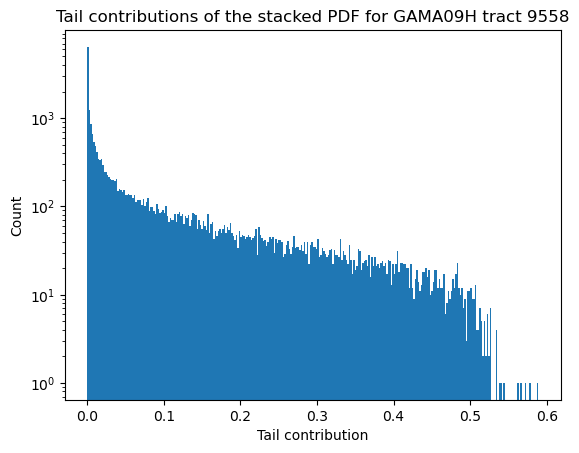

In [ ]:
plt.hist(tails, bins=300)
plt.xlabel('Tail contribution')
plt.ylabel('Count')
plt.title('Tail contributions of the stacked PDF for GAMA09H tract 9558')
plt.yscale('log')

In [ ]:
model = PySRRegressor(
    model_selection="best",
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    maxsize=15,
    verbosity=1
)

model.fit(X, y)

/global/homes/j/jeanchdj/.conda/envs/desi/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 2.750e+03
Progress: 13 / 3100 total iterations (0.419%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.461e-02  0.000e+00  y = 0.08719
3           3.966e-03  6.518e-01  y = x₁ - -0.047574
5           2.770e-03  1.794e-01  y = x₁ + (x₇ * 0.11953)
7           2.154e-03  1.258e-01  y = ((x₂ + x₄) - 0.084169) / 1.5293
9           2.114e-03  9.521e-03  y = (x₁ * 0.67982) + ((x₄ / 2.9144) * 1.0072)
11          1.653e-03  1.230e-01  y = (x₄ / 0.59999) * ((x₄ - (0.063193 - x₁)) / x₆)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluat

In [23]:
print(model)

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                                 x1   
	1        0.411357                                   x4 + -0.11601695   
	2        0.063638                    (x4 * 0.85929817) + -0.08742652   
	3  >>>>  0.197541               (x1 + (x4 - 0.08123776)) * 0.5395908   
	4        0.001974  ((x1 * 0.4701632) + (((x4 * 0.58913845) - 0.31...   
	5        0.001880  x1 + ((0.59043264 * (x4 - (x1 + (x0 / (-2.0513...   
	
	       loss  complexity  
	0  0.006229           1  
	1  0.002736           3  
	2  0.002409           5  
	3  0.001623           7  
	4  0.001604          13  
	5  0.001598          15  
]


In [117]:
model.equations_.iloc[2]

complexity                                                 5
loss                                                0.002409
equation                     (x4 * 0.85929817) + -0.08742652
score                                               0.063638
sympy_format                      x4*0.85929817 - 0.08742652
lambda_format    PySRFunction(X=>x4*0.85929817 - 0.08742652)
Name: 2, dtype: object

In [111]:
def get_area_ratio(sum, lim_tail):
    tail_range = (z_bins >= lim_tail)
    main_range = (z_bins < lim_tail)

    area_all = np.trapz(
        sum,
        z_bins
    )
    area_tail = np.trapz(
        sum[tail_range],
        z_bins[tail_range]
    )
    area_main = np.trapz(
        sum[main_range],
        z_bins[main_range]
    )
    # reduces tail with respect to main area, so
    # if we manage to have very small tail at the price of reducing a lot the main area,
    # the ratio will not be great; we are aiming for a small ratio
    return area_tail / area_main, area_tail / area_all, area_main / area_all

def parse_area_ratio(ratios):
    tail_main, tail_all, main_all = ratios
    return f'Tail/Main: {tail_main:.2%}\nTail/All: {tail_all:.2%}\nMain/All: {main_all:.2%}'

In [120]:
model.equations_.iloc[3].lambda_format

PySRFunction(X=>(x1 + x4 - 1*0.08123776)*0.5395908)

Removing 90th percentile: 0.0735


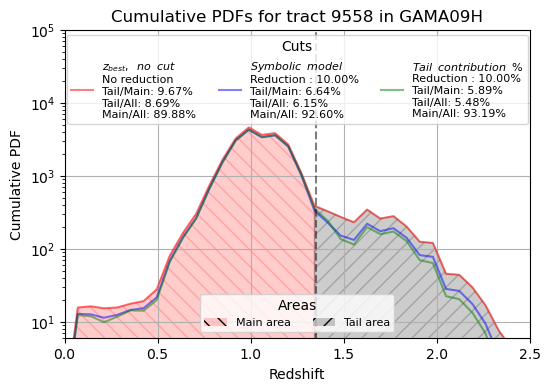

In [129]:
pct = 90
expression =  features[2] #(features[1] + (features[4] - 0.08123776)) * 0.5395908

rm_threshold = np.percentile(expression, pct)
print(f'Removing {pct}th percentile: {rm_threshold:.4f}')
rm_tail = expression < rm_threshold
tail_threshold = np.percentile(tails, pct)
tail_contrib = np.array(tails) < tail_threshold

fig, ax = plt.subplots(figsize=(6, 4))

best_sum = np.sum([p for _, p in filt_pdf], axis=0)
ax.plot(
    z_bins, 
    best_sum, 
    color='red', 
    label=r'$\it{z_{best},\;\;no\;\;cut}$' + f'\nNo reduction\n{parse_area_ratio(get_area_ratio(best_sum, lim_tail))}',
    alpha=0.5
    )
best_sum_rmt = np.sum([p for _, p in filt_pdf[rm_tail]], axis=0)
ax.plot(
    z_bins, 
    best_sum_rmt, 
    color='blue', 
    label=r'$\it{Symbolic\;\;model}$' + f'\nReduction : {1-np.sum(rm_tail)/len(rm_tail):.2%}\n{parse_area_ratio(get_area_ratio(best_sum_rmt, lim_tail))}',
    alpha=0.5
    )

best_sum_contrib = np.sum([p for _, p in filt_pdf[tail_contrib]], axis=0)
ax.plot(
    z_bins,
    best_sum_contrib,
    color='green',
    label=r'$\it{Tail\;\;contribution\;\;\%}$' + f'\nReduction : {1-np.sum(tail_contrib)/len(tail_contrib):.2%}\n{parse_area_ratio(get_area_ratio(best_sum_contrib, lim_tail))}',
    alpha=0.5
)

ax.axvline(
    x=lim_tail,
    color='black',
    linestyle='--',
    alpha=0.5
)
ax.fill_between(
    z_bins[z_bins < lim_tail],
    best_sum[z_bins < lim_tail],
    0,
    color='red',
    alpha=0.2,
    hatch='\\\\',
    interpolate=True,
)
ax.fill_between(
    z_bins[z_bins > lim_tail-0.007],
    best_sum[z_bins > lim_tail-0.007],
    0,
    color='black',
    alpha=0.2,
    interpolate=True,
    hatch='//'
)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.set_xlabel('Redshift')
ax.set_ylabel('Cumulative PDF')
legend1 = ax.legend(loc='upper center', fontsize=8, ncols=3, title='Cuts')
ax.set_title(f'Cumulative PDFs for tract {tract_id} in GAMA09H')
ax.grid()
ax.set_xlim(0, 2.5)
ax.set_yscale('log')
ax.set_ylim(6, 1e5)

ax.add_artist(legend1)
legend_elements = [
    Patch(facecolor='red', alpha=0.2, hatch='\\\\' ,label='Main area'),
    Patch(facecolor='black', alpha=0.2, hatch='//', label='Tail area'),
]
second_legend = ax.legend(
    handles=legend_elements,
    loc='lower center',  
    fontsize=8,
    ncols=2,
    title='Areas',
    frameon=True
)

In [38]:
for fn in feature_names:
    print(fn)

$z_{mean} - z_{median}$
$z_{mean} - z_{mode}$
$z_{median} - z_{mode}$
$i_{mag}$
$\sigma_{dnnz}$
$\sigma_{mizuki}$
$\sigma^{95,max}_{dnnz} - \sigma^{95,min}_{dnnz}$
$\sigma^{68,max}_{dnnz} - \sigma^{68,min}_{dnnz}$
$\sigma^{95,max}_{mizuki} - \sigma^{95,min}_{mizuki}$
$\sigma^{68,max}_{mizuki} - \sigma^{68,min}_{mizuki}$


(0.0, 3.0)

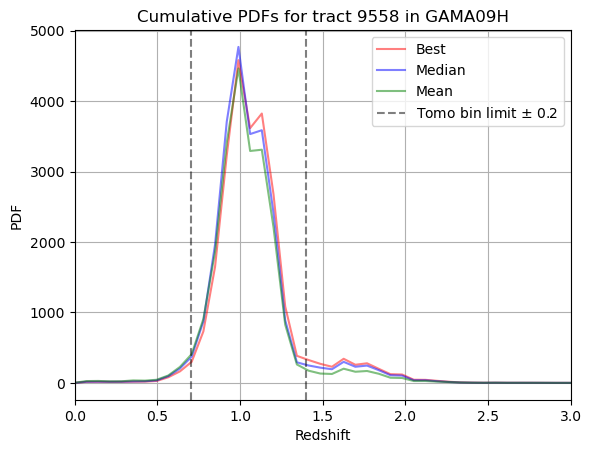

In [94]:
z_bins = np.linspace(0, 7, 100)
rm_tail = z['dnnz_photoz_mode'] - z['dnnz_photoz_median']
best_sum = np.sum([p for _, p in pdf[calibration_cut & zbin_crit_best]], axis=0)
median_sum = np.sum([p for _, p in pdf[calibration_cut & zbin_crit_median]], axis=0)
mean_sum = np.sum([p for _, p in pdf[calibration_cut & zbin_crit_mean]], axis=0)
plt.plot(
    z_bins, 
    best_sum, 
    color='red', 
    label='Best',
    alpha=0.5
    )
plt.plot(
    z_bins, 
    median_sum,
    color='blue', 
    label='Median',
    alpha=0.5
    )
plt.plot(
    z_bins, 
    mean_sum,
    color='green', 
    label='Mean',
    alpha=0.5
    )
area_ratio = 0
lim_low = bds_tomo[0] - 0.2
lim_tail = bds_tomo[1] + 0.2
plt.axvline(
    x=lim_low,
    color='black',
    linestyle='--',
    label='Tomo bin limit '+r'$\pm$'+' 0.2',
    alpha=0.5
)
plt.axvline(
    x=lim_tail,
    color='black',
    linestyle='--',
    alpha=0.5
)

tail_range = (z_bins >= lim_tail)
main_range = (z_bins < lim_low) | (z_bins > lim_tail)

area_tail = np.trapz(
    best_sum[tail_range],
    z_bins[tail_range]
)
area_main = np.trapz(
    best_sum[main_range],
    z_bins[main_range]
)
plt.xlabel('Redshift')
plt.ylabel('PDF')
plt.legend()
plt.title(f'Cumulative PDFs for tract {tract_id} in GAMA09H')
plt.grid()
plt.xlim(0, 3)

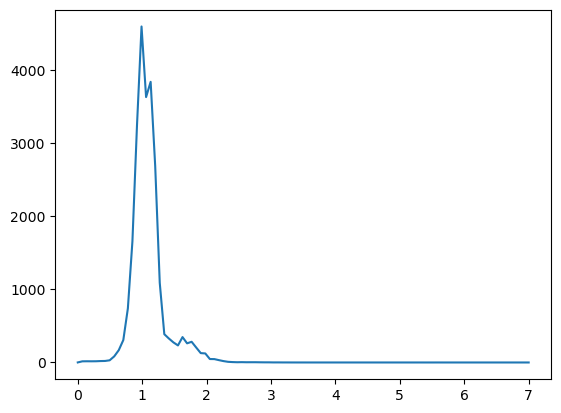

In [19]:
plt.plot(np.linspace(0, 7, 100), np.sum([p for _, p in pdf[zbin_crit]], axis=0))

In [ ]:
plt.plot()